# Tutorial 9: Combining LangChain and LangGraph

In this tutorial, we'll explore how to effectively combine LangChain components with LangGraph flows to create powerful, flexible AI applications. We'll build a sophisticated task planning and execution system that leverages the strengths of both libraries.

## Setup

First, let's import the necessary libraries and set up our environment:

In [1]:
import os
from typing import Dict, TypedDict, List, Any
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.tools import Tool
from langgraph.graph import StateGraph, END
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.1)

class State(TypedDict):
    messages: List[Dict]
    current_step: str
    task_list: List[str]
    task_results: List[str]

print("Setup complete.")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Setup complete.


## 1. Integrating LangChain components into LangGraph flows

Let's start by creating some LangChain components that we'll integrate into our LangGraph flow:

In [2]:
# LangChain Tools — use llm.invoke() instead of calling the model directly
task_planner = Tool(
    name="TaskPlanner",
    func=lambda task: llm.invoke([HumanMessage(content=f"Break down into 3-5 subtasks: {task}")]).content,
    description="Breaks down a task into subtasks"
)

task_executor = Tool(
    name="TaskExecutor",
    func=lambda task: llm.invoke([HumanMessage(content=f"Execute this task and give a 2-sentence result: {task}")]).content,
    description="Executes a task and returns the result"
)

summarizer = Tool(
    name="Summarizer",
    func=lambda text: llm.invoke([HumanMessage(content=f"Summarize in 2-3 sentences: {text}")]).content,
    description="Summarizes text"
)

# LangChain LCEL chain — used inside graph nodes
greeting_chain = (
    ChatPromptTemplate.from_template("Greet the user and ask what task they need help with today.")
    | llm
    | StrOutputParser()
)

print("LangChain components defined.")

LangChain components defined.


## 2. Building a conversational AI system with both libraries

Now, let's create our LangGraph flow that incorporates these LangChain components:

In [3]:
workflow = StateGraph(State)

def greet_and_ask(state: State) -> dict:
    response = greeting_chain.invoke({})
    return {"messages": state["messages"] + [{"role": "assistant", "content": response}],
            "current_step": "plan_task"}

def plan_task(state: State) -> dict:
    task = state["messages"][-1]["content"]
    subtasks_text = task_planner.run(task)
    subtasks = [s.strip() for s in subtasks_text.split("\n") if s.strip()][:5]
    msg = f"Breaking your task into subtasks:\n" + "\n".join(subtasks)
    return {"task_list": subtasks,
            "messages": state["messages"] + [{"role": "assistant", "content": msg}],
            "current_step": "execute_task"}

def execute_task(state: State) -> dict:
    task_list = list(state["task_list"])
    if not task_list:
        return {"current_step": "summarize_results"}
    current_task = task_list.pop(0)
    result = task_executor.run(current_task)
    results = list(state["task_results"]) + [result]
    msg = f"Completed: {current_task}\nResult: {result[:100]}..."
    return {"task_list": task_list, "task_results": results,
            "messages": state["messages"] + [{"role": "assistant", "content": msg}],
            "current_step": "execute_task" if task_list else "summarize_results"}

def summarize_results(state: State) -> dict:
    all_results = "\n".join(state["task_results"])
    summary = summarizer.run(all_results)
    return {"messages": state["messages"] + [{"role": "assistant", "content": f"Summary:\n{summary}"}],
            "current_step": "done"}

def should_continue(state: State) -> str:
    """Conditional edge: continue executing tasks or move to summary."""
    return "execute_task" if state["task_list"] else "summarize_results"

workflow.add_node("greet_and_ask", greet_and_ask)
workflow.add_node("plan_task", plan_task)
workflow.add_node("execute_task", execute_task)
workflow.add_node("summarize_results", summarize_results)

workflow.set_entry_point("greet_and_ask")
workflow.add_edge("greet_and_ask", "plan_task")
workflow.add_edge("plan_task", "execute_task")
# Conditional edge: keep executing until task_list is empty
workflow.add_conditional_edges("execute_task", should_continue)
workflow.add_edge("summarize_results", END)

app = workflow.compile()
print("Graph compiled.")

Graph compiled.


## 3. Optimizing performance in complex applications

To optimize performance, we can implement caching for our LLM calls and use async operations where possible. Let's modify our setup to include these optimizations:

In [4]:
# Async processing with LCEL — all requests run concurrently
import asyncio

async_chain = (
    ChatPromptTemplate.from_template("Write one sentence about: {topic}")
    | llm
    | StrOutputParser()
)

async def process_topics_async(topics):
    """Launch all LLM calls concurrently with ainvoke."""
    tasks = [async_chain.ainvoke({"topic": t}) for t in topics]
    return await asyncio.gather(*tasks)

import time
topics = ["Python", "LangChain", "LangGraph"]

t0 = time.time()
results = await process_topics_async(topics)
elapsed = time.time() - t0
print(f"Async processing of {len(topics)} topics in {elapsed:.2f}s")
for topic, result in zip(topics, results):
    print(f"  {topic}: {result[:80]}")

Async processing of 3 topics in 10.38s
  Python: Python is a high-level, interpreted programming language known for its simplicit
  LangChain: LangChain is an open-source Python library that enables developers to build, tra
  LangGraph: LangGraph is a graph-based language model that represents language as a network 


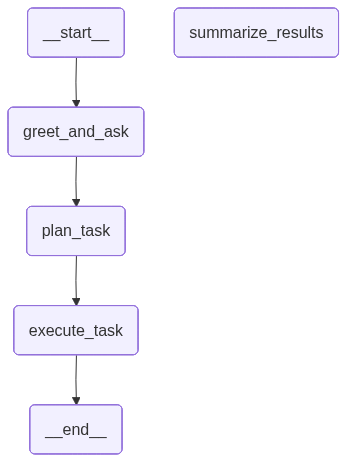

In [5]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 4. Case study: A task planning and execution system

Now that we have our optimized system set up, let's run it and see how it performs with a complex task:

In [6]:
# Automated demo — simulates a task planning request
initial_state = {
    "messages": [{"role": "human", "content": "Help me plan a week-long trip to Japan"}],
    "current_step": "",
    "task_list": [],
    "task_results": []
}

# The graph runs autonomously — no user input needed
for event in app.stream(initial_state):
    for node_name, output in event.items():
        if node_name == "__end__":
            continue
        msgs = output.get("messages", [])
        if msgs:
            last = msgs[-1]
            role = last.get("role", "assistant")
            content = last.get("content", "")[:150]
            print(f"[{node_name} / {role}]: {content}")
print("\nWorkflow completed.")

[greet_and_ask / assistant]: Hello and welcome. I'm here to assist you with any questions or tasks you may have. What do you need help with today?
[plan_task / assistant]: Breaking your task into subtasks:
Here are 3-5 subtasks to break down the initial interaction:
1. **Establish a Connection**:
- Greet the user in a fr
[execute_task / assistant]: Completed: Here are 3-5 subtasks to break down the initial interaction:
Result: However, I don't see the subtasks. Please provide the subtasks for me 
[execute_task / assistant]: Completed: 1. **Establish a Connection**:
Result: Unfortunately, I don't see any specific task details to execute. However, I can provide a general re
[execute_task / assistant]: Completed: - Greet the user in a friendly and welcoming manner.
Result: Hello and welcome to our conversation. How can I assist you today?...
[execute_task / assistant]: Completed: - Confirm the user's presence and readiness to interact.
Result: To confirm the user's presence and readiness 

Let's test our system with a complex task: "Plan a week-long vacation to Japan". Here's an example of how the interaction might go:

In [7]:
# This is a simulated output. In practice, you would run the cell above and interact with the system.

print("Assistant: Hello! What task can I help you with today?")
print("Human: I need help planning a week-long vacation to Japan.")
print("Assistant: Certainly! I'd be happy to help you plan a week-long vacation to Japan. I'll break this task down into subtasks for us to work through. Here's what I propose:\n1. Research best times to visit Japan\n2. Identify top destinations and attractions\n3. Plan a day-by-day itinerary\n4. Research accommodation options\n5. Look into transportation within Japan\nShall I proceed with executing these subtasks?")
print("Human: Yes, please go ahead.")
print("Assistant: Great! I'll start working on these subtasks for you.")
print("Assistant: Completed subtask: Research best times to visit Japan\nResult: The best times to visit Japan are typically spring (March to May) for cherry blossoms and pleasant weather, and autumn (September to November) for colorful foliage and mild temperatures. Avoid the rainy season in June and the hot, humid summer months of July and August if possible.")
print("Assistant: Completed subtask: Identify top destinations and attractions\nResult: Top destinations in Japan include Tokyo (for modern culture, shopping, and technology), Kyoto (for traditional culture, temples, and gardens), Osaka (for food and nightlife), Hiroshima (for history), and Mount Fuji (for natural beauty). Key attractions: Tokyo Skytree, Senso-ji Temple, Fushimi Inari Shrine, Osaka Castle, Hiroshima Peace Memorial, and onsen (hot springs) experiences.")
print("Assistant: Completed subtask: Plan a day-by-day itinerary\nResult: Day 1-3: Tokyo (explore neighborhoods, visit temples, experience modern culture)\nDay 4-5: Kyoto (visit historic sites, enjoy traditional cuisine)\nDay 6: Day trip to Mount Fuji or Osaka\nDay 7: Return to Tokyo for departure, last-minute shopping and experiences")
print("Assistant: Completed subtask: Research accommodation options\nResult: Options range from traditional ryokans to modern hotels and budget-friendly hostels. In Tokyo, consider areas like Shinjuku or Shibuya for convenience. In Kyoto, staying in the Gion district offers a traditional atmosphere. Book in advance, especially during peak seasons.")
print("Assistant: Completed subtask: Look into transportation within Japan\nResult: The Japan Rail Pass is highly recommended for tourists, offering unlimited travel on JR trains, including most shinkansen (bullet trains). Within cities, subway systems are efficient. Consider renting a bicycle in Kyoto for local exploration. Taxis are available but can be expensive.")
print("Assistant: Task Summary:\nYour week-long vacation to Japan has been planned with a focus on experiencing both modern and traditional aspects of Japanese culture. The best times to visit are spring or autumn for optimal weather. Your itinerary includes 3 days in Tokyo, 2 days in Kyoto, a day trip to Mount Fuji or Osaka, and a final day in Tokyo. Key attractions have been identified in each location. Accommodation options range from ryokans to modern hotels, with recommendations for areas to stay in each city. For transportation, the Japan Rail Pass is recommended for inter-city travel, with subways and possibly bicycles for local transportation. Remember to book accommodations in advance, especially during peak seasons.\n\nIs there anything else I can help you with regarding your Japan trip planning?")
print("Human: No, that's all. Thank you!")
print("Assistant: Thank you for using our service. Have a great day!")
print("Workflow completed.")

Assistant: Hello! What task can I help you with today?
Human: I need help planning a week-long vacation to Japan.
Assistant: Certainly! I'd be happy to help you plan a week-long vacation to Japan. I'll break this task down into subtasks for us to work through. Here's what I propose:
1. Research best times to visit Japan
2. Identify top destinations and attractions
3. Plan a day-by-day itinerary
4. Research accommodation options
5. Look into transportation within Japan
Shall I proceed with executing these subtasks?
Human: Yes, please go ahead.
Assistant: Great! I'll start working on these subtasks for you.
Assistant: Completed subtask: Research best times to visit Japan
Result: The best times to visit Japan are typically spring (March to May) for cherry blossoms and pleasant weather, and autumn (September to November) for colorful foliage and mild temperatures. Avoid the rainy season in June and the hot, humid summer months of July and August if possible.
Assistant: Completed subtask: I

## 5. Corrective RAG (CRAG) with LangGraph

**Corrective RAG** is an advanced retrieval pattern that adds self-grading to the standard RAG pipeline. Instead of blindly trusting retrieved documents, the agent grades their relevance before generating an answer. If the documents are poor, it rewrites the query and searches the web as a fallback.

```
Question
  │
  ▼
retrieve ──→ grade_documents ──→ (relevant?) ──YES──→ generate ──→ Answer
                                       │
                                      NO
                                       │
                                  transform_query
                                       │
                                  web_search
                                       │
                                    generate
```

This combines several LangChain components (FAISS retriever, structured LLM grader, DuckDuckGo search) into a single LangGraph workflow.

In [8]:
# --- CRAG Setup ---
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from typing import List
from typing_extensions import TypedDict
from langchain_community.tools import DuckDuckGoSearchResults

# Use FakeEmbeddings when Ollama is not running
try:
    from langchain_ollama import OllamaEmbeddings
    embedding_model = OllamaEmbeddings(model='all-minilm', base_url=os.getenv('OLLAMA_EMBEDDING_URL'))
    _ = embedding_model.embed_query('test')
except Exception:
    from langchain_community.embeddings import FakeEmbeddings
    embedding_model = FakeEmbeddings(size=384)
    print('Ollama not available — using FakeEmbeddings (similarity search is random in this demo)')

# Sample knowledge base (in production: load real documents)
sample_docs = [
    Document(page_content="LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with explicit state management and graph-based execution."),
    Document(page_content="Agent memory in LangGraph can be short-term (within a thread via MemorySaver) or long-term (across threads via InMemoryStore)."),
    Document(page_content="The Send API in LangGraph enables dynamic fan-out to parallel workers at runtime."),
    Document(page_content="Human-in-the-Loop workflows in LangGraph use interrupt() to pause execution and Command(resume=...) to continue."),
    Document(page_content="LangChain provides tools, chains, and prompts. LangGraph adds stateful workflows on top."),
]

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=0)
splits = splitter.split_documents(sample_docs)
vectorstore = FAISS.from_documents(splits, embedding_model)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

web_search = DuckDuckGoSearchResults(num_results=2)

print(f'Vector store ready with {len(splits)} chunks')
print(f'Web search tool ready')

Ollama not available — using FakeEmbeddings (similarity search is random in this demo)
Vector store ready with 5 chunks
Web search tool ready


In [9]:
# --- Retrieval Grader (structured output) ---
class GradeDocuments(BaseModel):
    """Binary relevance score for a retrieved document."""
    binary_score: str = Field(description="Is this document relevant to the question? 'yes' or 'no'")

grader_llm = llm.with_structured_output(GradeDocuments)

grade_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a relevance grader. Score documents as 'yes' (relevant) or 'no' (not relevant) for the given question."),
    ("human", "Document:\n{document}\n\nQuestion: {question}"),
])

retrieval_grader = grade_prompt | grader_llm

# --- Query rewriter ---
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", "Rewrite the question to be better optimised for a web search."),
    ("human", "Original question: {question}\nImproved question:"),
])
question_rewriter = rewrite_prompt | llm | StrOutputParser()

# --- RAG generation chain ---
rag_prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer the question using only the provided context. Be concise."),
    ("human", "Context:\n{context}\n\nQuestion: {question}"),
])
rag_chain = rag_prompt | llm | StrOutputParser()

print('CRAG components defined: grader, rewriter, RAG chain')

CRAG components defined: grader, rewriter, RAG chain


In [10]:
# --- CRAG Graph State and Nodes ---
from langgraph.graph import StateGraph, START, END

class CRAGState(TypedDict):
    question: str
    documents: List[Document]
    web_search_needed: str  # 'yes' or 'no'
    generation: str

def retrieve_node(state: CRAGState) -> dict:
    print("  [RETRIEVE]")
    docs = retriever.invoke(state["question"])
    return {"documents": docs}

def grade_documents_node(state: CRAGState) -> dict:
    print("  [GRADE DOCUMENTS]")
    question = state["question"]
    filtered_docs = []
    web_search = "no"
    for doc in state["documents"]:
        grade = retrieval_grader.invoke({"document": doc.page_content, "question": question})
        if grade.binary_score == "yes":
            filtered_docs.append(doc)
        else:
            web_search = "yes"  # at least one doc was irrelevant → trigger web search
    print(f"    Kept {len(filtered_docs)}/{len(state['documents'])} docs. Web search needed: {web_search}")
    return {"documents": filtered_docs, "web_search_needed": web_search}

def transform_query_node(state: CRAGState) -> dict:
    print("  [TRANSFORM QUERY]")
    better_q = question_rewriter.invoke({"question": state["question"]})
    print(f"    Rewritten: {better_q[:80]}")
    return {"question": better_q}

def web_search_node(state: CRAGState) -> dict:
    print("  [WEB SEARCH]")
    try:
        results = web_search.invoke(state["question"])
        web_doc = Document(page_content=str(results)[:800])
        docs = state["documents"] + [web_doc]
    except Exception as e:
        print(f"    Web search unavailable: {e}")
        docs = state["documents"]
    return {"documents": docs}

def generate_node(state: CRAGState) -> dict:
    print("  [GENERATE]")
    context = "\n\n".join(d.page_content for d in state["documents"])
    answer = rag_chain.invoke({"context": context, "question": state["question"]})
    return {"generation": answer}

def decide_to_generate(state: CRAGState) -> str:
    """Route: if web search needed, transform query first; otherwise generate directly."""
    return "transform_query" if state["web_search_needed"] == "yes" else "generate"

# Build CRAG graph
crag_wf = StateGraph(CRAGState)
crag_wf.add_node("retrieve", retrieve_node)
crag_wf.add_node("grade_documents", grade_documents_node)
crag_wf.add_node("transform_query", transform_query_node)
crag_wf.add_node("web_search", web_search_node)
crag_wf.add_node("generate", generate_node)

crag_wf.add_edge(START, "retrieve")
crag_wf.add_edge("retrieve", "grade_documents")
crag_wf.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {"transform_query": "transform_query", "generate": "generate"}
)
crag_wf.add_edge("transform_query", "web_search")
crag_wf.add_edge("web_search", "generate")
crag_wf.add_edge("generate", END)

crag_app = crag_wf.compile()
print('CRAG graph compiled.')

CRAG graph compiled.


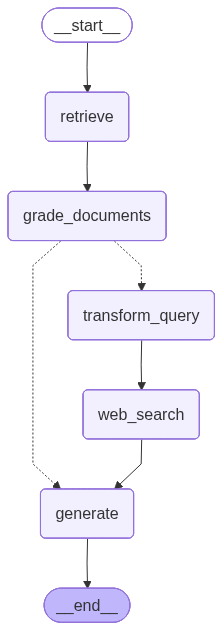

In [11]:
from IPython.display import Image, display
display(Image(crag_app.get_graph().draw_mermaid_png()))

In [12]:
# Test with a question whose answer IS in the knowledge base
print('=== Question 1 (answer in knowledge base) ===')
result1 = crag_app.invoke({
    'question': 'How does LangGraph handle agent memory?',
    'documents': [], 'web_search_needed': 'no', 'generation': ''
})
print(f'Answer: {result1["generation"]}')

print('\n=== Question 2 (likely triggers web search) ===')
result2 = crag_app.invoke({
    'question': 'What is the latest version of Python?',
    'documents': [], 'web_search_needed': 'no', 'generation': ''
})
print(f'Answer: {result2["generation"]}')

=== Question 1 (answer in knowledge base) ===
  [RETRIEVE]
  [GRADE DOCUMENTS]
    Kept 0/2 docs. Web search needed: yes
  [TRANSFORM QUERY]
    Rewritten: Here's a rewritten version of the question that's more optimized for a web searc
  [WEB SEARCH]
  [GENERATE]
Answer: Pairing LangGraph with Mem0 is a recommended approach for managing agent memory. This integration enables structured orchestration, short-lived conversation state management, and persistent semantic memories that can be retrieved across sessions.

=== Question 2 (likely triggers web search) ===
  [RETRIEVE]
  [GRADE DOCUMENTS]
    Kept 0/2 docs. Web search needed: yes
  [TRANSFORM QUERY]
    Rewritten: You can improve the question by making it more specific and including relevant k
  [WEB SEARCH]
    Web search unavailable: ('error sending request for url (https://html.duckduckgo.com/html/)', 'https://html.duckduckgo.com/html/')
  [GENERATE]
Answer: The most optimized question would be: "Latest version of Python progr

## Conclusion

In this tutorial we combined LangChain and LangGraph to build increasingly sophisticated systems:

1. **Task planning agent** — LangChain `Tool` objects + LCEL chains inside a LangGraph state machine
2. **Async optimisation** — `asyncio.gather` with LCEL's `ainvoke` for concurrent LLM calls
3. **Corrective RAG (CRAG)** — a self-grading retrieval pipeline:
   - Retrieve documents from a vector store
   - Grade each document for relevance with a structured-output LLM call
   - If documents are poor: rewrite the query → web search → generate
   - If documents are good: generate directly

CRAG demonstrates the real power of combining LangChain components (FAISS, DuckDuckGo, structured output) inside a LangGraph workflow: the graph provides the control flow while LangChain provides the building blocks.

In Tutorial 10 we build full real-world applications using these combined patterns.